In [1]:
import numpy as np
import matplotlib.pyplot as plt
from magnonics import *
from configs_slab.elongated_triangular_slabs import *

In [2]:
hamil, lat, basis = Initialize.from_csv('configs/elongated_triangular.csv')

hamil.HP_trafo(symbolic=True)

hamil.parameterize_hamil()

Automatically finding sufficient chemical potential...
Using 1e-10 as chemical potential.


1e-10

In [3]:
hamil.lat.num_rcpr_vects.T# @ np.array(([0.4641016], [0.7320508], [0]))

array([[ 6.28318531,  0.        ,  0.        ],
       [-1.68357443,  3.36714886,  0.        ],
       [ 0.        ,  0.        ,  6.28318531]])

In [4]:
r1, r2, _ = hamil.lat.num_vects
ang12 = HighSymmetryPoints.angle_between(r1, r2) # 75° or 5pi/12 = 1.30899694 for elongated triangular
b = norm(r1)    # 1
c = norm(r2)    # sqrt(2 + sqrt(3))

eta = (1 - (b / c) * np.cos(ang12)) / (2 * (np.sin(ang12))**2) # 2*sqrt(3) - 3 ~ 0.4641016
nu = 1/2 - eta * (c / b) * np.cos(ang12)                       # 2 - sqrt(3) ~ 0.2679492

print(r1, r2, ang12, b, c, eta, nu, sep='\n')

[1. 0. 0.]
[0.5       1.8660254 0.       ]
1.3089969389957472
1.0
1.9318516525781366
0.46410161513775455
0.26794919243112275


['$\\Gamma$', (0, 0, 0)]
['X', (0.5, 0, 0)]
['Y', (0, 0.5, 0)]
['C', (0.5, 0.5, 0)]
['H', (np.float64(0.46410161513775455), np.float64(0.7320508075688772), 0)]
['H1', (np.float64(0.5358983848622454), np.float64(0.26794919243112275), 0)]


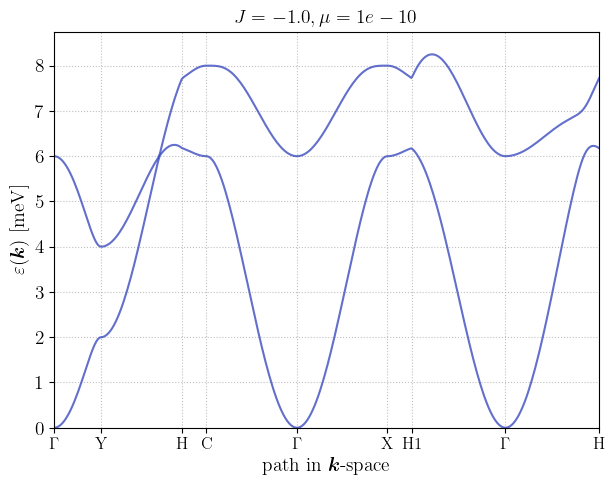

In [5]:
bz = ObliqueAFLOW(hamil, 'elongated_triangular')
hsp = bz.hsp
print(hsp.g, hsp.x, hsp.y, hsp.c, hsp.h, hsp.h1, sep='\n')
disp = bz.get_dispersion(hsp.g, hsp.y, hsp.h, hsp.c, hsp.g, hsp.x, hsp.h1, hsp.g, hsp.h, num = 300) # (hsp.g, hsp.y, hsp.h, hsp.c, hsp.h1, hsp.x, hsp.g, num = 300)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=False)
bz.save_plot(fig, overwrite=True)

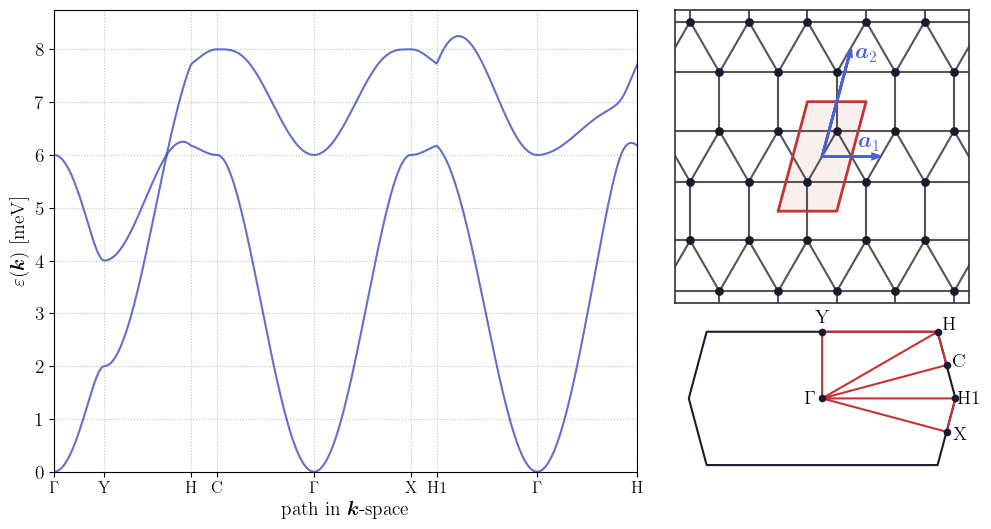

In [6]:
from numpy import sqrt

a = 1

a1 = (a, 0)
a2 = (a/2, (1+sqrt(3)/2)*a)

base_pos = [
    (0.0, 0.0),
    (0.26794919, 0.46410162)
]

both = bz.plot_bs_and_lat(disp, 
                          a1, a2, base_pos, 
                          BZ_type='oblique',
                        #   cell_origin=(-1/3, -1/4),
                          n_shells=4,
                          view_size=2.5,
                          vect_label_offset_a1 = (-0.2, 0.25),
                          vect_label_offset_a2 = (0.25, -0.1),
                          figsize = (12,6),
                          wratio = [1.8, 1],
                          hratio = [2, 1],
                          wspace = 0.05,
                          hspace = 0.1,)

bz.save_plot(both, overwrite=True, filename='elongated_triangular_BS_combined')

In [ ]:
hamil.update_parameters({'Dz': -0.1}, 1e-8)

Updated parameters and now using 1e-08 as chemical potential.


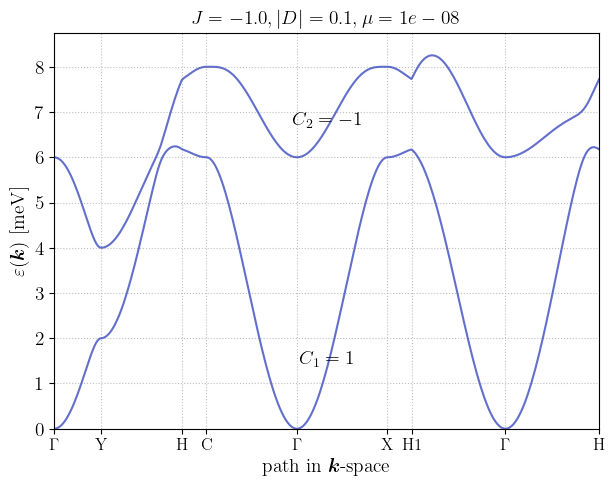

In [ ]:
bz = ObliqueAFLOW(hamil, 'elongated_triangular')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.y, hsp.h, hsp.c, hsp.g, hsp.x, hsp.h1, hsp.g, hsp.h, num = 300) # old is g x a1 y g
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)

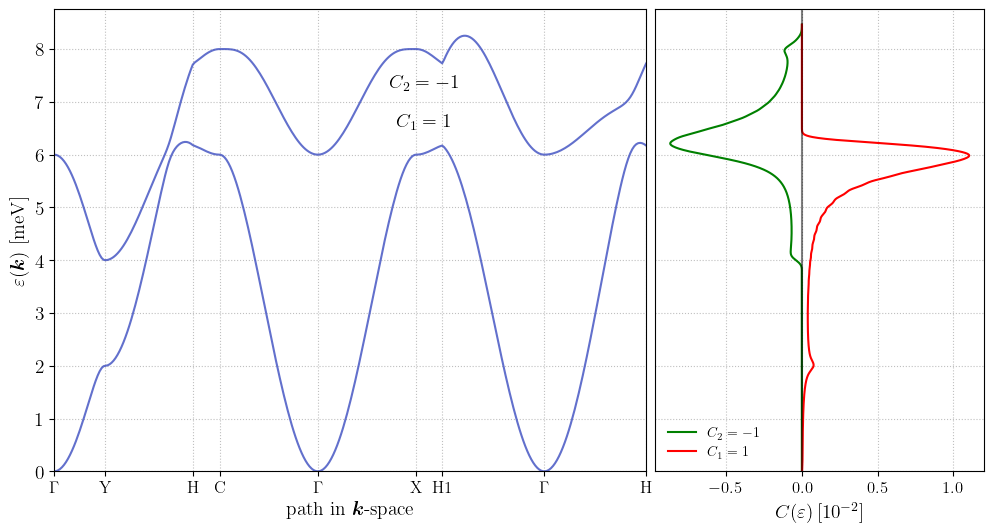

In [ ]:
chern = bz.plot_bs_and_chern(disp,
                             chern_gridsize = 50,
                             sigma = 0.07,
                             points = 5000,
                             figsize = (12,6),
                             wratio = [1.8, 1],
                             wspace = 0.02,
                             loc='lower left',
                             label_margin=0.3)

bz.save_plot(chern, overwrite=True, filename='elongated_triangular_chern')

In [ ]:
Es, EVs = hamil.evgrid(60)

hamil.chern(EVs)

chern_numbers = np.around(hamil.chern(EVs), 2)

print(chern_numbers[:len(chern_numbers) // 2])
print(np.sum(chern_numbers[:len(chern_numbers) // 2],0))

[-1.  1.]
0.0


Processing 2 bands with mixed shapes...


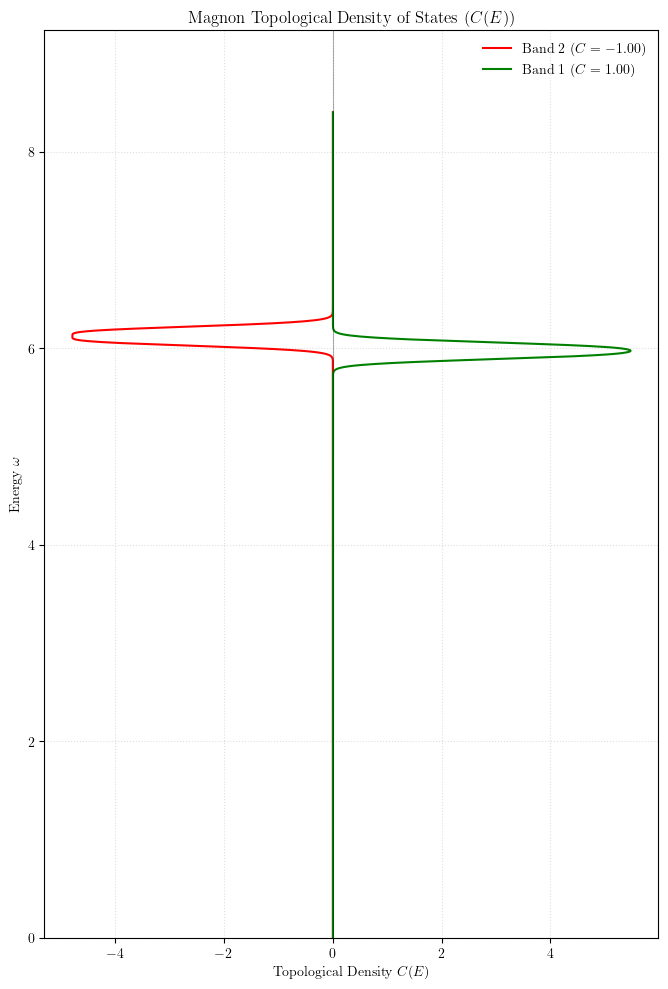

In [ ]:
# params
sigma = 0.05
n_points = 5000
F_12 = - hamil.curvature_grid(EVs)

n_bands = F_12.shape[0]  # Get number of bands from the leading dim of F_12
    
# 1. Setup Energy Axis
e_min, e_max = np.min(Es) - 3*sigma, np.max(Es) + 3*sigma
energy_axis = np.linspace(e_min, e_max, n_points)

chern_density = np.zeros((n_points, n_bands))

print(f"Processing {n_bands // 2} bands with mixed shapes...")
for b in range(n_bands // 2):
    # F_12 is (Nbands, Nk1-1, Nk2-1) -> e.g., (N, 9, 9)
    # E is (Nk1, Nk2, Nbands) -> e.g., (10, 10, N)
    
    # 1. Match the shapes
    # We take the energy of the bottom-left corner of each plaquette
    nk1_flux, nk2_flux = F_12.shape[1], F_12.shape[2]
    
    energies_b = Es[:nk1_flux, :nk2_flux, b].ravel() # Slice E to (9, 9)
    flux_b = F_12[b].ravel()                        # Already (9, 9)
    
    # Now both are length 81
    diff = energy_axis[:, np.newaxis] - energies_b[np.newaxis, :]
    weights = (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (diff / sigma)**2)
    
    chern_density[:, b] = (weights @ flux_b) / (2 * np.pi)

# 4. Visualization
plt.figure(figsize=(7, 10))
total_density = np.sum(chern_density, axis=1)

colors = ['r', 'g', 'b', 'c', 'm', 'y']

for b in range(n_bands//2):
    c_val = np.sum(F_12[b]) / (2 * np.pi)
    plt.plot(chern_density[:, b], energy_axis, 
                label=f'Band {n_bands // 2 - b} ($C={c_val:.2f}$)', color=colors[b])

# plt.plot(total_density, energy_axis, 'k--', alpha=0.5, label='Total Sum')

plt.axvline(0, color='black', lw=0.8, alpha=0.3)
plt.xlabel(r"Topological Density $C(E)$")
plt.ylabel(r"Energy $\omega$")
plt.title(r"Magnon Topological Density of States ($C(E)$)")
plt.legend(frameon=False)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.ylim(ymin=0)
plt.show()

In [ ]:
width1 = 90
flat_flat = build_flat_flat(width1)

Setup file saved to: c:\Users\Pascal\Desktop\magnon_code\archimedean\configs_slab\elongated_triangular_flat_flat.csv


In [ ]:
flat_flat, _, _ = Initialize.from_csv('configs_slab/elongated_triangular_flat_flat.csv')

flat_flat.HP_trafo(symbolic=True) ;

In [ ]:
flat_flat.update_parameters({'Dz': -0.1}, 1e-3)

Updated parameters and now using 0.001 as chemical potential.


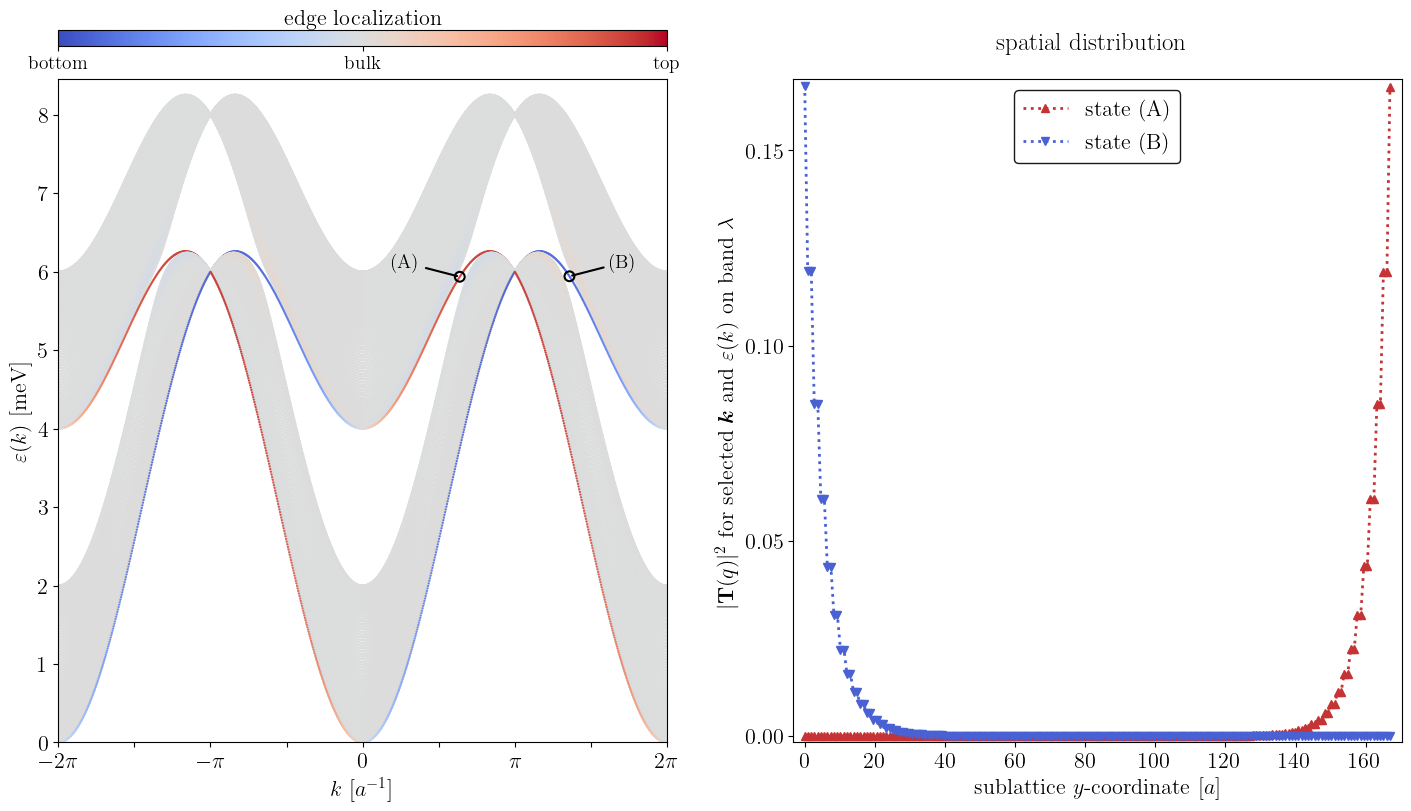

In [ ]:
slab1 = Slab(flat_flat, 'elongated_triangular') # FIXME lattice plot is misaligned

state_A1 = [0.32, 5.85, '(A)', 5, 135]
state_B1 = [0.68, 5.85, '(B)', 5, 45]

fig1_bs = slab1.slab_bandplot(n_unitcells = width1, k_space = 'full', states = [state_A1, state_B1])

slab1.save_plot(fig1_bs, filename = 'elongated_triangular_flat_flat_bs', format= '.png', overwrite = True)

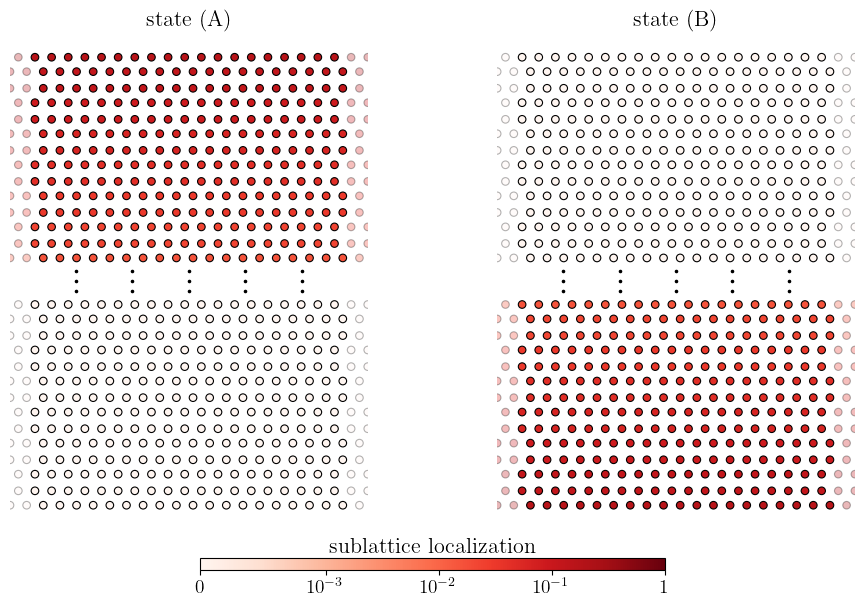

In [ ]:
fig1_lat = slab1.slab_latticeplot(n_unitcells = width1, states = [state_A1, state_B1], reps = 26, gap_dot_scale = (50, 8), edge_layers = 7)

slab1.save_plot(fig1_lat, filename = 'elongated_triangular_flat_flat_lat', format= '.png', overwrite = True)

In [ ]:
width2 = 90
zigzag_zigzag = build_zigzag_zigzag(width2)

Setup file saved to: c:\Users\Pascal\Desktop\magnon_code\archimedean\configs_slab\elongated_triangular_zigzag_zigzag.csv


In [ ]:
zigzag_zigzag, _, _ = Initialize.from_csv('configs_slab/elongated_triangular_zigzag_zigzag.csv')

zigzag_zigzag.HP_trafo(symbolic=True) ;

In [ ]:
zigzag_zigzag.update_parameters({'Dz': -0.3}, 1e-2)

Updated parameters and now using 0.01 as chemical potential.


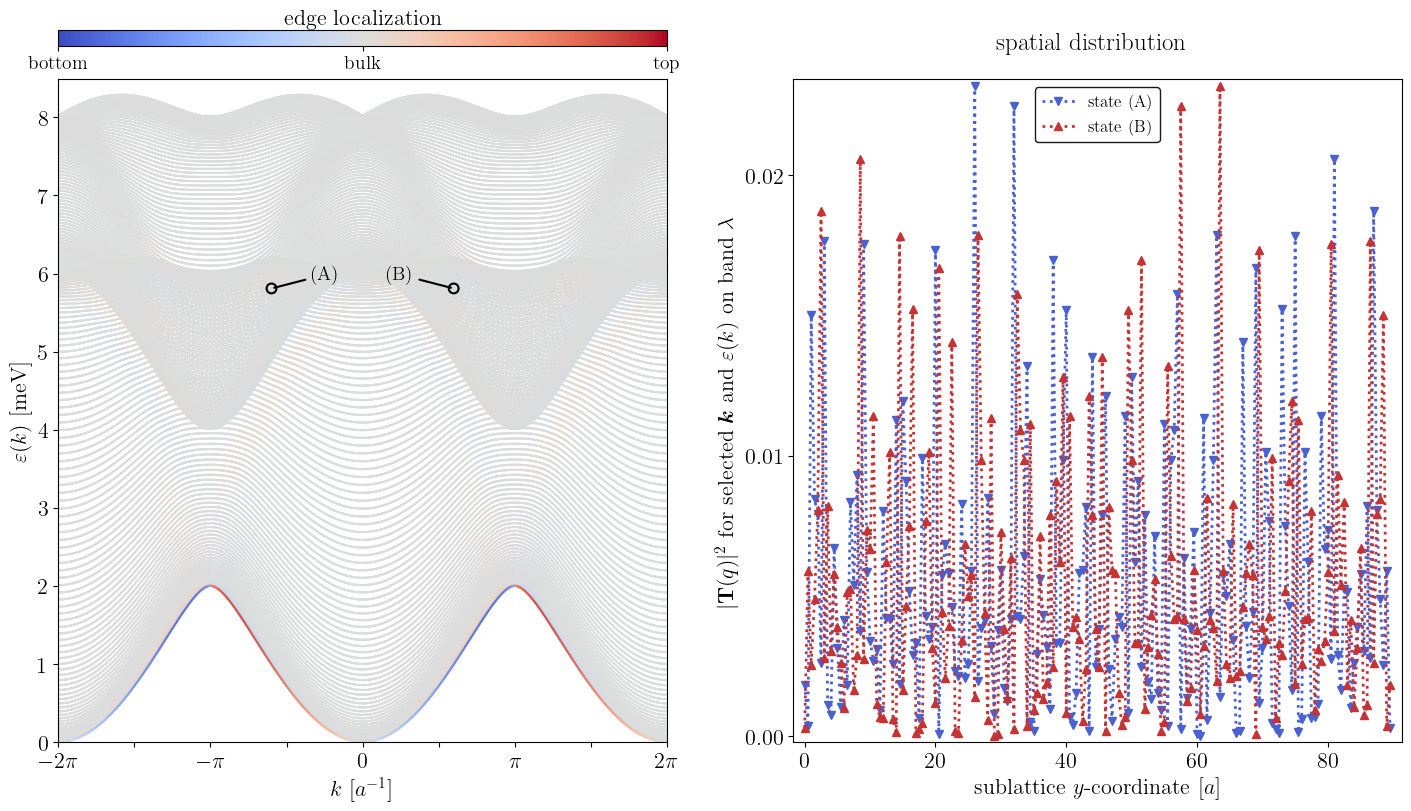

In [ ]:
slab2 = Slab(zigzag_zigzag, 'elongated_triangular')

state_A2 = [-0.3, 5.8, '(A)', 5, 45]
state_B2 = [0.3, 5.8, '(B)', 5, 135]

fig2_bs = slab2.slab_bandplot(n_unitcells = width2, k_space = 'full', states = [state_A2, state_B2])

slab2.save_plot(fig2_bs, filename = 'elongated_triangular_zigzag_zigzag_bs', overwrite = True)

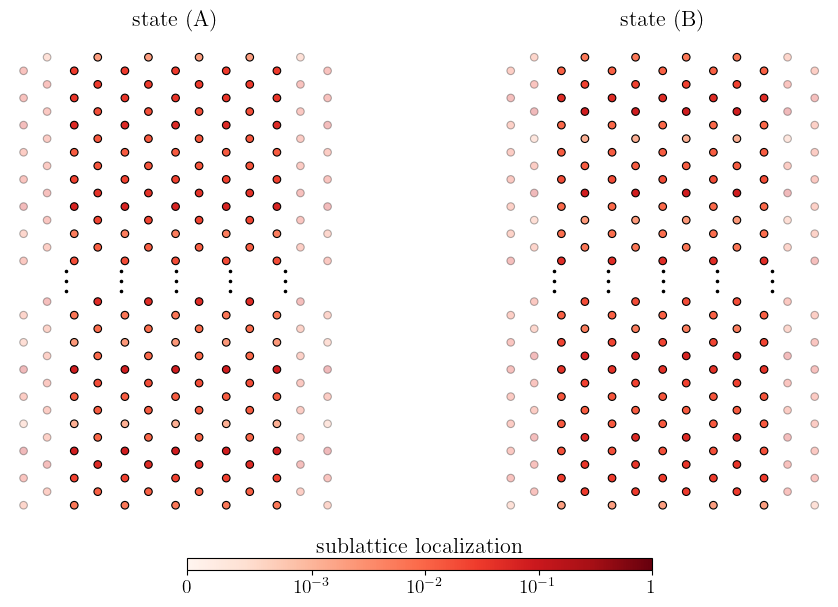

In [ ]:
fig2_lat = slab2.slab_latticeplot(n_unitcells = width2, states = [state_A2, state_B2], reps = 8, gap_dot_scale = (15, 3), edge_layers = 8)

slab2.save_plot(fig2_lat, filename = 'elongated_triangular_zigzag_zigzag_lat', overwrite = True)

In [ ]:
width3 = 90
hook_hook = build_hook_hook(width3)

Setup file saved to: c:\Users\Pascal\Desktop\magnon_code\archimedean\configs_slab\elongated_triangular_hook_hook.csv


In [ ]:
hook_hook, _, _ = Initialize.from_csv('configs_slab/elongated_triangular_hook_hook.csv')

hook_hook.HP_trafo(symbolic=True) ;

In [ ]:
hook_hook.update_parameters({'Dz': -0.3}, 1e-2)

Updated parameters and now using 0.01 as chemical potential.


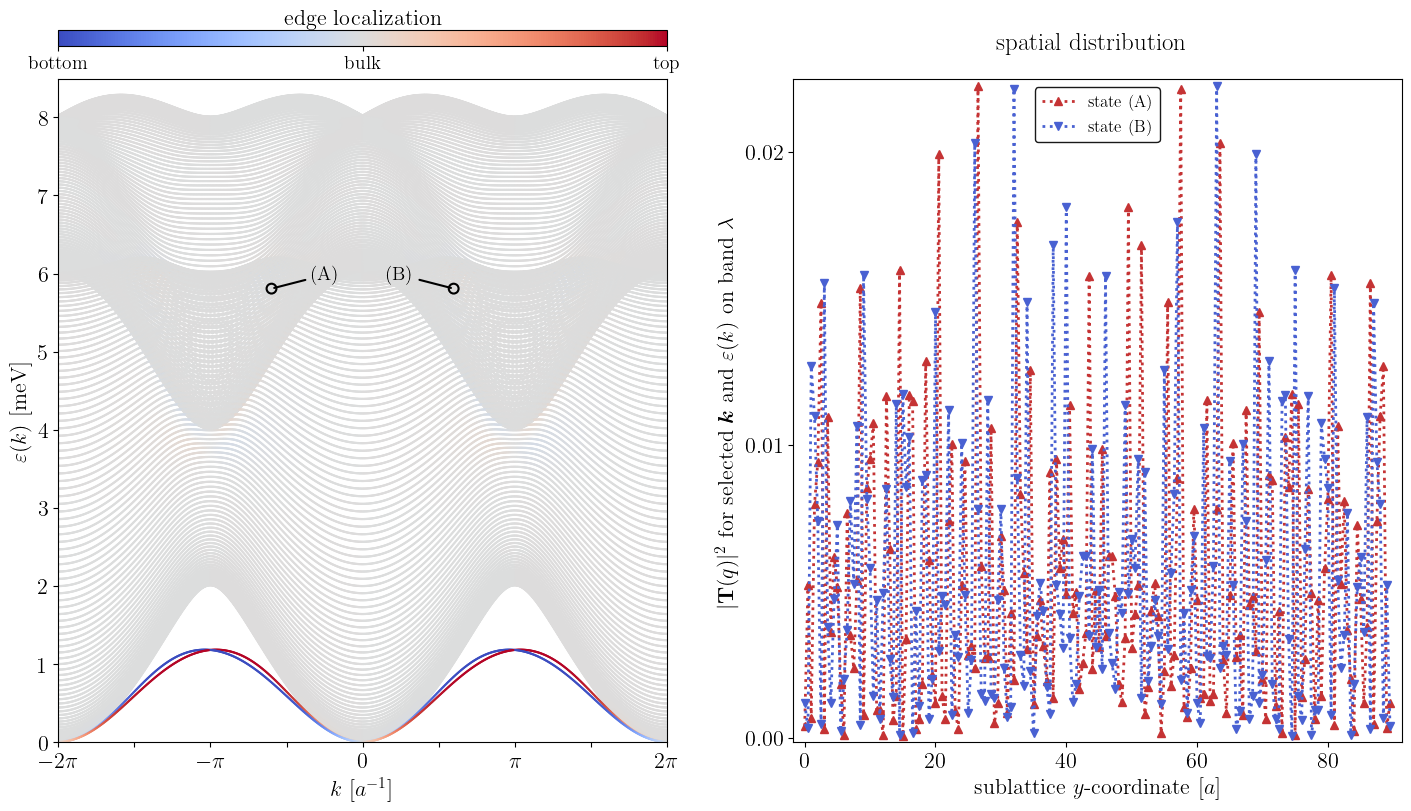

In [ ]:
slab3 = Slab(hook_hook, 'elongated_triangular')

state_A3 = [-0.3, 5.8, '(A)', 5, 45]
state_B3 = [0.3, 5.8, '(B)', 5, 135]

fig3_bs = slab3.slab_bandplot(n_unitcells = width3, k_space = 'full', states = [state_A3, state_B3])

slab3.save_plot(fig3_bs, filename = 'elongated_triangular_hook_hook_bs', overwrite = True)

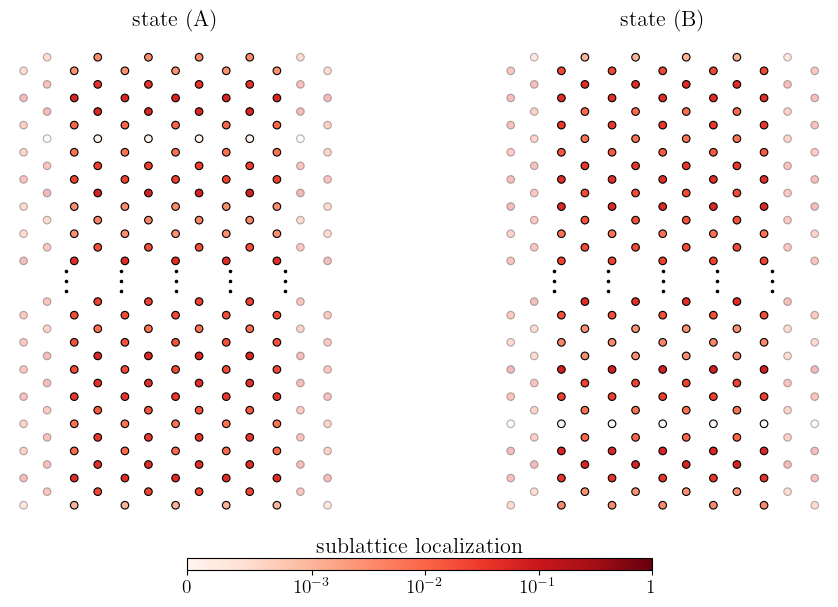

In [ ]:
fig3_lat = slab3.slab_latticeplot(n_unitcells = width3, states = [state_A3, state_B3], reps = 8, gap_dot_scale = (15, 3), edge_layers = 8)

slab3.save_plot(fig3_lat, filename = 'elongated_triangular_hook_hook_lat', overwrite = True)